In [52]:
import numpy as np
import matplotlib.pyplot as plt

In [53]:
def Adaptive_Forward_Difference_21(f,t,epsilon,rl,ru,inter):
    # algoritmo 2.1
    h=2*np.sqrt(epsilon)/np.sqrt(3)
    l=0
    u=np.infty
    i=0
    while True:
        r=np.abs(f(t+4*h)-4*f(t+h)+3*f(t))/(8*epsilon)
        if r<rl:
            l=h
        elif r>ru:
            u=h
        else:
            break
        if u==np.infty:
            h*=4
        elif l==0:
            h/=4
        else:
            h=(l+u)/2
        if i>inter:
            break
        i+=1
    return h




In [54]:
def r_s(f,t,s,w,h,d,epsilon):
    res=np.sum(w*f(t+h*s))/(epsilon*h**d)
    return res
def Adaptive_Forward_Difference_31(f,t,s,w,h0,eta,epsilon,d,rl,ru,rs,intera):
    # algoritmo 3.1
    h=np.copy(h0)
    l=0
    u=np.infty
    inter=0
    while True:
        r=rs(f,t,s,w,h,d,epsilon)
        if r<rl:
            l=h
        elif r>ru:
            u=h
        else:
            break
        if u==np.infty:
            h*=eta
        elif l==0:
            h/=eta
        else:
            h=(l+u)/2
        if inter>intera:
            break
        inter+=1
    return h

In [55]:
def first_order_central_diff(f,t,h):
    # primera derivada central
    v_d_f=[]
    for i in range(len(t)):
        ei=np.zeros_like(t)
        ei[i]=1
        fs_r=(f(t+h*ei)-f(t-h*ei))/(2*h) 
        v_d_f.append(fs_r)   

    return np.array(v_d_f)

def second_order_central_diff(f,t,h):
    # segunda derivada central
    v_d_f=[]
    for i in range(len(t)):
        ei=np.zeros_like(t)
        ei[i]=1
        fs_r=(f(t+h*ei)-2*f(t)-f(t-h*ei))/(h**2)    
        v_d_f.append(fs_r)   

    return np.array(v_d_f)

def diff_d_th(f,t,s,w,h,d):
    # derivada d-th orden
    v_d_f=[]
    for i in range(len(t)):
        ei=np.zeros_like(t)
        ei[i]=1
        suma=0
        for sj,wj in zip(s,w):
            suma+=wj*f(t+h*sj*ei)
        v_d_f.append(suma/h**d)
    return np.array(v_d_f)


In [56]:
def backtracking(fun,x,fun_xk,p,grad_xk,alpha,c_1,rho,inter_b):
    alpha_i=np.copy(alpha)
    for i in range(inter_b):
        fun_alphai=fun(x+alpha_i*p)
        cond=fun_alphai<=fun_xk+c_1*alpha_i*np.dot(grad_xk,p)
        if cond:
            return  alpha_i, i
        alpha_i*=rho
    return  max(alpha_i,1e-8), i

def BFGS_mod( f,g,H,tao,N,x,alpha,c_1,inter_b,rho_back,lambda_1=10**(-5),lambda_2=10**(-5),guardar=False):
    v_x=[]
    v_g=[]
    v_f=[]
    x_i=x
    f_i=f(x)
    g_i=g(x_i)
    H_i=np.copy(H)
    dim=H.shape
    I=np.eye(dim[0])
    res=0
    alpha_g=np.copy(alpha)
    for i in range(N):
        alpha=np.copy(alpha_g)
        n_g_i=np.linalg.norm(g_i)
        if guardar:
            v_x.append(np.copy(x_i))
            v_g.append(np.copy(g_i))
            v_f.append(np.copy(f_i))
        if n_g_i<tao:
            res=1
            break
        p_i=-np.dot(H_i,g_i)
        pg=np.dot(p_i,g_i)
        if pg>0:
            gg=np.dot(g_i,g_i)
            lambda_1=10**(-5)+pg/gg
            H_i+=lambda_1*I
            p_i-=lambda_1*g_i
        alpha,j=backtracking(f,x_i,f_i,p_i,g_i,alpha,c_1,rho_back,inter_b)
        x_ip1=x_i+alpha*p_i
        s_i=x_ip1-x_i
        g_ip1=g(x_ip1)
        y_i=g_ip1-g_i
        ys=np.dot(y_i,s_i)
        if ys<=0: 
            lambda_2=10**(-5)-ys/np.dot(y_i,y_i)
            H_i+=lambda_2*I
        else:
            rho=1/ys
            sy=np.outer(s_i,y_i)
            sy_o=np.outer(y_i,s_i)
            H_i=np.dot(I-rho*sy,np.dot(H_i,(I-rho*sy_o)))+rho*np.outer(s_i,s_i)
        x_i=x_ip1
        g_i=g_ip1
        f_i=f(x_i)

    if guardar:
        return  x_i,g_i,f_i,i,np.array(v_x),np.array(v_g),np.array(v_f),res
    else:
        return x_i,g_i,f_i,i,res

In [57]:
from sympy import symbols, Eq,expand,collect,latex

# Parámetros
E, rho, c, k = symbols(r'E \rho c k')
Δx, Δt, x_i = symbols('Δx Δt x_i')

# Variables discretas
y_i2 = symbols('y_{i-2}')
y_i1 = symbols('y_{i-1}')
y_i = symbols('y_i')
y_i1p = symbols('y_{i+1}')
y_i2p = symbols('y_{i+2}')

yijm1 = symbols('y_i^{j-1}')
yij = symbols('y_i^j')
yijp1 = symbols('y_i^{j+1}')

# Coeficiente
coef = (-0.1 * x_i + 0.1)**2

# Términos
term1 = coef * E * (y_i2 - 4*y_i1 + 6*y_i - 4*y_i1p + y_i2p) / Δx**4
term2 = rho * coef * (yijp1 - 2*yij + yijm1) / Δt**2
term3 = c * (yijp1 - yijm1) / (2*Δt)
term4 = k * yij

# Ecuación
eq = Eq(term1 + term2 + term3 + term4, 0)

# Mostrar la ecuación
eq
eq_1=expand(eq.lhs)
eq_2=collect(eq_1, [y_i2,y_i1,y_i,y_i1p,y_i2p,yijm1,yij,yijp1])
display(eq_2)
latex_code=latex(eq_2)
print(latex_code)

y_i*(0.06*E*x_i**2/Δx**4 - 0.12*E*x_i/Δx**4 + 0.06*E/Δx**4) + y_i^j*(-0.02*\rho*x_i**2/Δt**2 + 0.04*\rho*x_i/Δt**2 - 0.02*\rho/Δt**2 + k) + y_i^{j+1}*(0.01*\rho*x_i**2/Δt**2 - 0.02*\rho*x_i/Δt**2 + 0.01*\rho/Δt**2 + c/(2*Δt)) + y_i^{j-1}*(0.01*\rho*x_i**2/Δt**2 - 0.02*\rho*x_i/Δt**2 + 0.01*\rho/Δt**2 - c/(2*Δt)) + y_{i+1}*(-0.04*E*x_i**2/Δx**4 + 0.08*E*x_i/Δx**4 - 0.04*E/Δx**4) + y_{i+2}*(0.01*E*x_i**2/Δx**4 - 0.02*E*x_i/Δx**4 + 0.01*E/Δx**4) + y_{i-1}*(-0.04*E*x_i**2/Δx**4 + 0.08*E*x_i/Δx**4 - 0.04*E/Δx**4) + y_{i-2}*(0.01*E*x_i**2/Δx**4 - 0.02*E*x_i/Δx**4 + 0.01*E/Δx**4)

y_{i} \left(\frac{0.06 E x_{i}^{2}}{Δx^{4}} - \frac{0.12 E x_{i}}{Δx^{4}} + \frac{0.06 E}{Δx^{4}}\right) + y^{j}_{i} \left(- \frac{0.02 \rho x_{i}^{2}}{Δt^{2}} + \frac{0.04 \rho x_{i}}{Δt^{2}} - \frac{0.02 \rho}{Δt^{2}} + k\right) + y_i^{j+1} \left(\frac{0.01 \rho x_{i}^{2}}{Δt^{2}} - \frac{0.02 \rho x_{i}}{Δt^{2}} + \frac{0.01 \rho}{Δt^{2}} + \frac{c}{2 Δt}\right) + y_i^{j-1} \left(\frac{0.01 \rho x_{i}^{2}}{Δt^{2}} - \frac{0.02 \rho x_{i}}{Δt^{2}} + \frac{0.01 \rho}{Δt^{2}} - \frac{c}{2 Δt}\right) + y_{i+1} \left(- \frac{0.04 E x_{i}^{2}}{Δx^{4}} + \frac{0.08 E x_{i}}{Δx^{4}} - \frac{0.04 E}{Δx^{4}}\right) + y_{i+2} \left(\frac{0.01 E x_{i}^{2}}{Δx^{4}} - \frac{0.02 E x_{i}}{Δx^{4}} + \frac{0.01 E}{Δx^{4}}\right) + y_{i-1} \left(- \frac{0.04 E x_{i}^{2}}{Δx^{4}} + \frac{0.08 E x_{i}}{Δx^{4}} - \frac{0.04 E}{Δx^{4}}\right) + y_{i-2} \left(\frac{0.01 E x_{i}^{2}}{Δx^{4}} - \frac{0.02 E x_{i}}{Δx^{4}} + \frac{0.01 E}{Δx^{4}}\right)


In [58]:
E=200*10**9 #Pa= N/m^2
rho=7800 #kg/m^3
c=0.1 #Ns/m
k=0.01#N/m
x=[0,1] #m
t=[0,600] #s


In [59]:
def c_0(x_i,dx,dt):
    rc_0=(0.06*E*x_i**2)/(dx**4)-(0.12*E*x_i)/(dx**4)+(0.06*E)/(dx**4)
    return rc_0
def c_1(x_i,dx,dt):
    rc_1=-(0.02*rho*x_i**2)/(dt**2)+(0.04*rho*x_i)/(dt**2)-(0.02*rho)/(dt**2)+k
    return rc_1
def c_2(x_i,dx,dt):
    rc_2=(0.01*rho*x_i**2)/(dt**2)-(0.02*rho*x_i)/(dt**2)+(0.01*rho)/(dt**2)+c/(2*dt)
    return rc_2
def c_3(x_i,dx,dt):
    rc_3=(0.01*rho*x_i**2)/(dt**2)-(0.02*rho*x_i)/(dt**2)+(0.01*rho)/(dt**2)-c/(2*dt)
    return rc_3
def c_4(x_i,dx,dt):
    rc_4=-(0.04*E*x_i**2)/(dx**4)+(0.08*E*x_i)/(dx**4)-(0.04*E)/(dx**4)
    return rc_4
def c_5(x_i,dx,dt):
    rc_5=(0.01*E*x_i**2)/(dx**4)-(0.02*E*x_i)/(dx**4)+(0.01*E)/(dx**4)
    return rc_5


In [60]:
def fun_f(t):
    return 100*np.sin(10*t)

In [61]:
def f_A(x,dx,dt):
    dim=len(x[1:])
    A=np.zeros((dim,dim))
    i=np.arange(dim)
    A[0,0]=4*c_4(x[1],dx,dt)+16*c_5(x[1],dx,dt)
    A[0,1]=4*c_5(x[2],dx,dt)

    A[i,i]=c_0(x[1:],dx,dt)+c_1(x[1:],dx,dt)
    A[i[:-1],i[1:]]=c_4(x[2:],dx,dt)
    A[i[:-2],i[2:]]=c_5(x[3:],dx,dt)
    A[i[1:],i[:-1]]=c_4(x[:-2],dx,dt)
    A[i[2:],i[:-2]]=c_5(x[:-3],dx,dt)
    A[-1,:]=0
    I_1=(-0.1*x[-1]+0.1)**4
    A[-1,-3]=-3*E*I_1/(dx**3)
    A[-1,-2]=3*E*I_1/(dx**3)+c_4(x[-2],dx,dt)
    A[-1,-1]=-3*E*I_1/(dx**3)+c_0(x[-3],dx,dt)+c_1(x[-2],dx,dt)+2*c_4(x[-1],dx,dt)
    return A

In [62]:
def f_b(y_jl1,x,dx,dt,f_f,t):
    ma_c3=np.diag(c_3(x[1:],dx,dt))
    ext=np.zeros_like(y_jl1[1:])
    ext[1]=f_f(t)
    b=np.dot(ma_c3,y_jl1[1:])+ext
    return b

In [63]:
def iterracion(y_j,y_jl1,x,dx,dt,f_f,t):
    A_e=f_A(x,dx,dt)
    ma_c2=np.diag(1/c_2(x[1:],dx,dt))
    v_b=f_b(y_jl1,x,dx,dt,f_f,t)
    y_jp1=np.zeros_like(x)
    y_jp1[1:]=np.dot(ma_c2,np.dot(A_e,y_j[1:])+v_b)
    return y_jp1


In [64]:
v_x=np.linspace(x[0],x[1],100)
v_t=np.linspace(t[0],t[1],600)
y_jl1=np.zeros_like(v_x)
y_j=np.zeros_like(v_x)
v_y_j=[y_j]
for ti in v_t:
    y_jp1=iterracion(y_j,y_jl1,v_x,v_x[1],v_t[1],fun_f,ti)
    y_jl1=np.copy(y_j)
    y_j=np.copy(y_jp1)
    v_y_j.append(y_j)
print(v_y_j)

[array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([ 0.        ,  0.        , -0.74711601,  0.        ,  0.        ,
        0.        ,  0.        ,  0.   

Progreso: 0.1%
Progreso: 10.1%
Progreso: 20.1%


C:\Users\chris\AppData\Local\Temp\ipykernel_10892\1168491805.py:76: RuntimeWarning: overflow encountered in matmul
  y_jp1[1:-1] = (A @ y_j[1:-1] + b) / c2
C:\Users\chris\AppData\Local\Temp\ipykernel_10892\1168491805.py:80: RuntimeWarning: invalid value encountered in scalar subtract
  y_jp1[-1] = 2*y_jp1[-2] - y_jp1[-3]  # Condición de momento nulo
C:\Users\chris\AppData\Local\Temp\ipykernel_10892\1168491805.py:76: RuntimeWarning: invalid value encountered in matmul
  y_jp1[1:-1] = (A @ y_j[1:-1] + b) / c2


Progreso: 30.1%
Progreso: 40.1%
Progreso: 50.2%
Progreso: 60.2%
Progreso: 70.2%
Progreso: 80.2%
Progreso: 90.2%


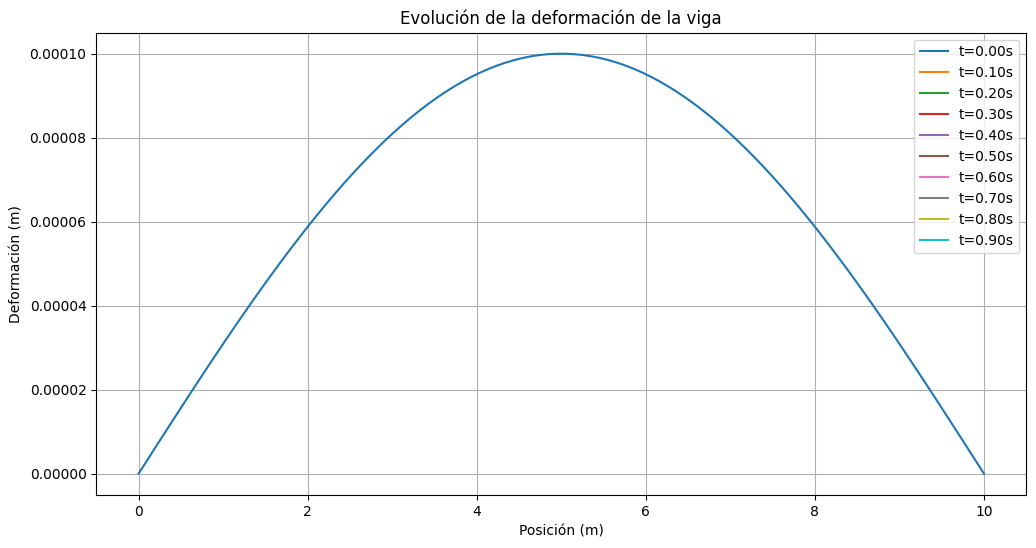

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Parámetros físicos (modifica estos valores según necesites)
E = 2.1e11  # Módulo de Young (Pa)
rho = 7800   # Densidad (kg/m³)
c = 5        # Coeficiente de amortiguamiento (reduce este valor)
k = 1     # Rigidez del suelo (N/m)
L = 10     # Longitud de la viga (m)
T = 1.0      # Tiempo total de simulación (s)

def c_0(x_i, dx, dt):
    return (0.06*E*x_i**2 - 0.12*E*x_i + 0.06*E) / dx**4

def c_1(x_i, dx, dt):
    return (-0.02*rho*x_i**2 + 0.04*rho*x_i - 0.02*rho) / dt**2 + k

def c_2(x_i, dx, dt):
    return (0.01*rho*x_i**2 - 0.02*rho*x_i + 0.01*rho) / dt**2 + c/(2*dt)

def c_3(x_i, dx, dt):
    return (0.01*rho*x_i**2 - 0.02*rho*x_i + 0.01*rho) / dt**2 - c/(2*dt)

def c_4(x_i, dx, dt):
    return (-0.04*E*x_i**2 + 0.08*E*x_i - 0.04*E) / dx**4

def c_5(x_i, dx, dt):
    return (0.01*E*x_i**2 - 0.02*E*x_i + 0.01*E) / dx**4

def fun_f(t):
    # Fuerza sinusoidal más pronunciada
    return 1e6*np.sin(50*t)  # Aumenta la amplitud y frecuencia

def build_system_matrix(x, dx, dt):
    n = len(x) - 2  # Excluyendo los bordes
    A = np.zeros((n, n))
    
    # Coeficientes para puntos internos
    for i in range(n):
        xi = x[i+1]  # +1 porque ignoramos el primer punto
        
        A[i,i] = c_0(xi, dx, dt) + c_1(xi, dx, dt)
        
        if i > 0:
            A[i,i-1] = c_4(x[i], dx, dt)
        if i < n-1:
            A[i,i+1] = c_4(x[i+2], dx, dt)
        if i > 1:
            A[i,i-2] = c_5(x[i-1], dx, dt)
        if i < n-2:
            A[i,i+2] = c_5(x[i+3], dx, dt)
    
    # Condiciones de frontera
    I_1 = (-0.1*x[-1] + 0.1)**4
    A[-1,:] = 0
    A[-1,-3] = -3*E*I_1/dx**3
    A[-1,-2] = 3*E*I_1/dx**3 + c_4(x[-2], dx, dt)
    A[-1,-1] = -3*E*I_1/dx**3 + c_0(x[-2], dx, dt) + c_1(x[-2], dx, dt) + 2*c_4(x[-1], dx, dt)
    
    return A

def time_step(y_j, y_jm1, x, dx, dt, t):
    n = len(x) - 2
    A = build_system_matrix(x, dx, dt)
    
    c3 = c_3(x[1:-1], dx, dt)
    b = c3 * y_jm1[1:-1]
    
    # Aplicar fuerza en el extremo derecho
    b[-1] += (-0.1*x[-1] + 0.1)**4 * fun_f(t) * dx**3 / E
    
    c2 = c_2(x[1:-1], dx, dt)
    
    y_jp1 = np.zeros_like(x)
    y_jp1[1:-1] = (A @ y_j[1:-1] + b) / c2
    
    # Condiciones de frontera
    y_jp1[0] = 0  # Extremo fijo
    y_jp1[-1] = 2*y_jp1[-2] - y_jp1[-3]  # Condición de momento nulo
    
    return y_jp1

# Configuración de la simulación
Nx = 100  # Puntos espaciales
Nt = 1000 # Pasos temporales

v_x = np.linspace(0, L, Nx)
v_t = np.linspace(0, T, Nt)
dx = v_x[1] - v_x[0]
dt = v_t[1] - v_t[0]

# Condición inicial con pequeña perturbación
y_jm1 = np.zeros_like(v_x)
y_j = 1e-4 * np.sin(np.pi*v_x/L)  # Pequeña deformación inicial

# Almacenamiento de resultados
results = [y_j.copy()]

# Simulación
for i, t in enumerate(v_t[1:]):
    y_jp1 = time_step(y_j, y_jm1, v_x, dx, dt, t)
    y_jm1, y_j = y_j, y_jp1
    results.append(y_j.copy())
    

# Visualización
plt.figure(figsize=(12, 6))
for i in range(0, len(results), len(results)//10):
    plt.plot(v_x, results[i], label=f"t={v_t[i]:.2f}s")
plt.title("Evolución de la deformación de la viga")
plt.xlabel("Posición (m)")
plt.ylabel("Deformación (m)")
plt.legend()
plt.grid()
plt.show()